This script analyses SIPSCS/EPSCS analysis of GAD67 and NTSR1 lines
- the csv files are inside the /Users/rbondare/ephys/metadata/sIPSCs_sEPSCs
- this script is self sufficent and does not rely on anything else
- for Gad67 n=15 and for ntsr1 n=9 is analysed. the values were extracted by Peter and i manually transferred them to this notebook
- for both datasets Wilkson test was used due to non normality of the dataset (last script test for that)
- raw data for nstr1 is available (no raw data for Gad67 found (need to ask Peter))
- plotting the example traces themselves is iin the plotting_sIPSCs.ipynb script

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib
import pyabf 
import seaborn as sns
sns.set_context('talk')
import os
from scipy import stats

In [3]:
sEPSC_ntsr1_freq = {
        'Cell_ID': ['M1_C1', 'M1_C2', 'M1_C3', 'M2_C1', 'M2_C2', 'M2_C3', 'M6_C1', 'M6_C2', 'M6_C3'],
        'Animal': ['M1', 'M1', 'M1', 'M2', 'M2', 'M2', 'M6', 'M6', 'M6'],
        'Baseline_Frequency': [1.8677, 0.575, 1.0208, 0.5641, 1.2033, 0.9186, 3.4255, 1.7464, 1.0217],
        'NA_Frequency': [0.9283, 0.1662, 0.9855, 0.3319, 1.3427, 0.3547, 0.3552, 0.5639, 0.4719]
    }
    
sEPSC_ntsr1_ampl = {
        'Cell_ID': ['M1_C1', 'M1_C2', 'M1_C3', 'M2_C1', 'M2_C2', 'M2_C3', 'M6_C1', 'M6_C2', 'M6_C3'],
        'Animal': ['M1', 'M1', 'M1', 'M2', 'M2', 'M2', 'M6', 'M6', 'M6'],
        'Baseline_Amplitude': [7.5706, 6.7139, 6.1536, 5.188, 6.499, 4.9682, 7.8805, 6.1763, 4.6996],
        'NA_Amplitude': [7.8184, 7.0626, 6.8185, 5.2362, 5.7827 , 5.7086, 5.3993, 5.5099, 6.0505]
    }

sIPSC_ntsr1_freq = {
        'Cell_ID': ['M3_C1', 'M3_C2', 'M3_C3', 'M4_C1', 'M4_C2', 'M4_C3', 'M5_C1', 'M5_C2', 'M5_C3'],
        'Animal': ['M3', 'M3', 'M3', 'M4', 'M4', 'M4', 'M5', 'M5', 'M5'],
        'Baseline_Frequency': [1.1462, 0.563, 2.7665, 2.1435,0.3021,0.7454,0.8081,3.221020878,2.7158],
        'NA_Frequency': [13.281,5.2162,5.0844,2.5665,2.378,8.9352,2.4505,14.592,6.5217]
    }

sIPSC_ntsr1_ampl = {
        'Cell_ID': ['M3_C1', 'M3_C2', 'M3_C3', 'M4_C1', 'M4_C2', 'M4_C3', 'M5_C1', 'M5_C2', 'M5_C3'],
        'Animal': ['M3', 'M3', 'M3', 'M4', 'M4', 'M4', 'M5', 'M5', 'M5'],
        'Baseline_Amplitude': [10.198,6.7138,7.0191,7.4348,5.0756,12.802,5.9815,7.559096154,9.455],
        'NA_Amplitude': [7.8551,6.8923,8.0405,6.6456,8.4617,11.353,6.3087,13.425,7.3418]
    }


In [4]:
sEPSC_Gad67_freq = {
    'Cell_ID': ['M1_C1', 'M1_C2', 'M1_C3', 'M2_C1', 'M2_C2', 'M2_C3', 'M3_C1', 'M3_C2', 'M3_C3', 'M4_C1', 'M4_C2', 'M4_C3', 'M5_C1', 'M5_C2', 'M5_C3'],
    'Animal': ['M1', 'M1', 'M1', 'M2', 'M2', 'M2', 'M3', 'M3', 'M3', 'M4', 'M4', 'M4', 'M5', 'M5', 'M5'],
    'Baseline_Frequency': [1.0086, 0.2561, 3.0418, 1.9863, 7.5441, 2.9273, 3.6544, 1.4384, 0.9005, 4.5827, 13.808, 0.5264, 2.5691, 1.3247, 1.0313],
    'NA_Frequency': [1.9585, 0.1517, 5.3941, 2.3442, 7.3563, 3.3679, 7.4706, 2.2165, 0.812, 8.2118, 24.223, 2.2272, 11.774, 2.9194, 1.7295]
}

sEPSC_Gad67_ampl = {
    'Cell_ID': ['M1_C1', 'M1_C2', 'M1_C3', 'M2_C1', 'M2_C2', 'M2_C3', 'M3_C1', 'M3_C2', 'M3_C3', 'M4_C1', 'M4_C2', 'M4_C3', 'M5_C1', 'M5_C2', 'M5_C3'],
    'Animal': ['M1', 'M1', 'M1', 'M2', 'M2', 'M2', 'M3', 'M3', 'M3', 'M4', 'M4', 'M4', 'M5', 'M5', 'M5'],
    'Baseline_Amplitude': [6.4446, 5.4932, 9.7401, 7.7907, 9.8147, 10.673, 7.7534, 9.3481, 13.235, 12.809, 13.409, 7.0745, 21.076, 15.731, 12.778],
    'NA_Amplitude': [8.0008, 11.215, 9.5827, 12.109, 8.7378, 12.397, 7.1545, 9.3114, 9.9535, 10.013, 10.212, 7.0827, 18.285, 11.137, 12.346]
}

sIPSC_Gad67_freq = {
    'Cell_ID': ['M1_C1', 'M1_C2', 'M1_C3', 'M2_C1', 'M2_C2', 'M2_C3', 'M3_C1', 'M3_C2', 'M3_C3', 'M4_C1', 'M4_C2', 'M4_C3', 'M5_C1', 'M5_C2', 'M5_C3'],
    'Animal': ['M1', 'M1', 'M1', 'M2', 'M2', 'M2', 'M3', 'M3', 'M3', 'M4', 'M4', 'M4', 'M5', 'M5', 'M5'],
    'Baseline_Frequency': [0.6272, 0.149, 1.7039, 0.6419, 0.1978, 0.2319, 0.4106, 1.5999, 0.1948, 1.2751, 0.2411, 0.4877, 0.0827, 0.6229, 0.2523],
    'NA_Frequency': [1.086, 0.0648, 7.4388, 4.8996, 0.2967, 1.0022, 0.9678, 1.9486, 0.8286, 1.8771, 0.7785, 0.9436, 0.2305, 1.5879, 0.1887]
}

sIPSC_Gad67_ampl = {
    'Cell_ID': ['M1_C1', 'M1_C2', 'M1_C3', 'M2_C1', 'M2_C2', 'M2_C3', 'M3_C1', 'M3_C2', 'M3_C3', 'M4_C1', 'M4_C2', 'M4_C3', 'M5_C1', 'M5_C2', 'M5_C3'],
    'Animal': ['M1', 'M1', 'M1', 'M2', 'M2', 'M2', 'M3', 'M3', 'M3', 'M4', 'M4', 'M4', 'M5', 'M5', 'M5'],
    'Baseline_Amplitude': [5.7305, 4.1707, 7.5538, 7.9447, 6.2053, 5.0735, 5.0281, 7.986, 8.9519, 5.5295, 7.9685, 8.9782, 4.8826, 7.4366, 3.4877],
    'NA_Amplitude': [5.3163, 7.782, 9.1526, 8.8745, 8.9111, 7.1068, 7.585, 9.7527, 8.0184, 5.4163, 8.6818, 8.2915, 3.9513, 9.0303, 4.3945]
}

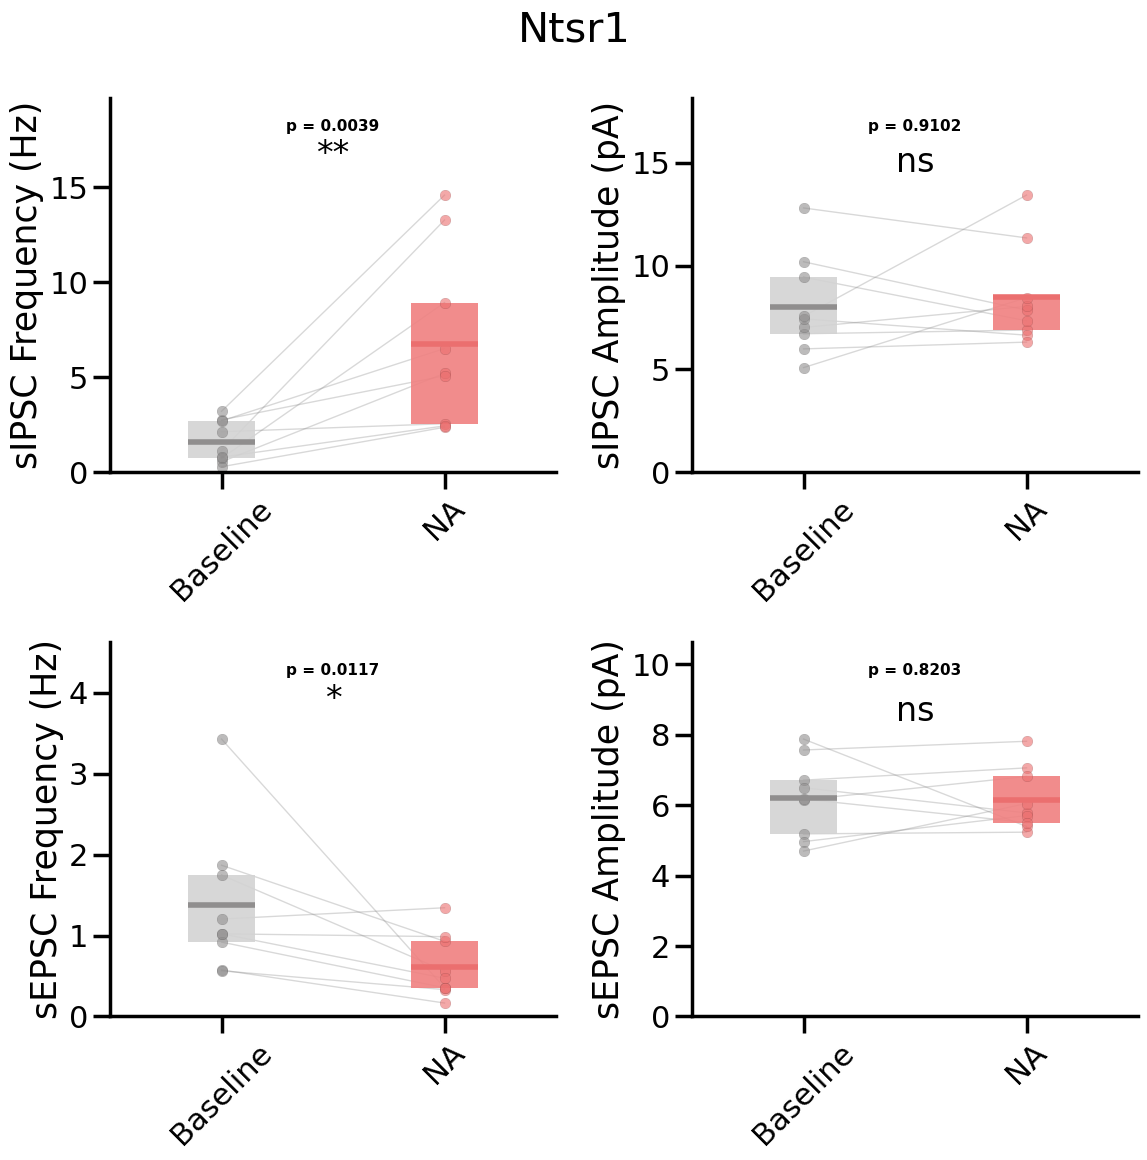

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib
import pyabf 
import seaborn as sns
sns.set_context('poster')
import os
from scipy import stats
from statannotations.Annotator import Annotator

def plot_epsc_ipsc():
    # Create DataFrames
    df_sEPSC_freq = pd.DataFrame(sEPSC_ntsr1_freq)
    df_sEPSC_ampl = pd.DataFrame(sEPSC_ntsr1_ampl)
    df_sIPSC_freq = pd.DataFrame(sIPSC_ntsr1_freq)
    df_sIPSC_ampl = pd.DataFrame(sIPSC_ntsr1_ampl)
    
    # Create 2x2 plot
    fig, axes = plt.subplots(2, 2, figsize=(12,12))
    plt.subplots_adjust(wspace=0.3, hspace=0.)
    
    # Your exact color scheme
    colors = ['lightgrey', 'lightcoral']  # baseline, NA
    colors_bar = ["#908E8E", "#EB6F6F"]  # baseline, NA
    conditions = ['baseline', 'NA']
    
    datasets = [
        (df_sIPSC_freq, 'Baseline_Frequency', 'NA_Frequency', 'sIPSC Frequency (Hz)', axes[0,0]),
        (df_sIPSC_ampl, 'Baseline_Amplitude', 'NA_Amplitude', 'sIPSC Amplitude (pA)', axes[0,1]),
        (df_sEPSC_freq, 'Baseline_Frequency', 'NA_Frequency', 'sEPSC Frequency (Hz)', axes[1,0]),
        (df_sEPSC_ampl, 'Baseline_Amplitude', 'NA_Amplitude', 'sEPSC Amplitude (pA)', axes[1,1])
    ]
    
    for df, baseline_col, na_col, ylabel, ax in datasets:
        box_data = [df[baseline_col].values, df[na_col].values]
        
        # Plot boxplots with your color scheme
        box = ax.boxplot(
            box_data,
            positions=range(len(conditions)),
            widths=0.3,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color='none'),
            boxprops=dict(facecolor='none', edgecolor='none'),
            whiskerprops=dict(color='none'),
            capprops=dict(color='none')
        )
        
        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.9)
        
        # Plot connected lines and points
        for _, row in df.iterrows():
            y = [row[baseline_col], row[na_col]]
            x = [0, 1]
            
            # Connect points with line
            ax.plot(x, y, color='gray', alpha=0.3, linewidth=1, zorder=1)
            
            for i, (xi, yi) in enumerate(zip(x, y)):
                ax.scatter(xi, yi, color=colors_bar[i], alpha=0.6, s=60, zorder=2,
                          edgecolors='black', linewidths=0.1)
        
        # Draw mean lines
        for i, col in enumerate([baseline_col, na_col]):
            box_width = 0.3  # Same as the boxplot width
            y_vals = df[col].dropna().values
            if len(y_vals) > 0:
                ax.hlines(np.mean(y_vals),  i - box_width/2, i + box_width/2,
                         color=colors_bar[i], linewidth=4, zorder=3)
        
        data_long = pd.DataFrame({
            'value': np.concatenate([df[baseline_col].values, df[na_col].values]),
            'group': ['Baseline'] * len(df[baseline_col]) + ['NA'] * len(df[na_col])
        })
        
        # Configure statannotations for stars only 
        pairs = [('Baseline', 'NA')]
        annotator = Annotator(ax, pairs, data=data_long, x='group', y='value')
        annotator.configure(
            test='Wilcoxon', 
            text_format='star',  # Use stars instead of p-values
            loc='outside',  # Place annotations outside the plot
            verbose=False,
            line_height=0,  # Remove the bracket lines
            line_width=0    # Remove the bracket lines
        )
        annotator.apply_and_annotate()
    
        # Get max_y for axis formatting
        max_y = max(df[baseline_col].max(), df[na_col].max())
        if max_y <= 0:
            max_y = 1
        
        # Also show numeric p-value above the star/ns annotation
        _, p_val = stats.wilcoxon(df[baseline_col], df[na_col], nan_policy='omit')
        p_text = f'p = {p_val:.4f}' if np.isfinite(p_val) else 'p = n/a'
        p_text_y = max_y + (max_y * 0.22)
        ax.text(0.5, p_text_y, p_text,
                ha='center', va='bottom', fontsize=11, fontweight='bold')
        
        # Format axes
        ax.set_ylabel(ylabel, fontsize=25)
        ax.set_xticks(range(len(conditions)))
        ax.set_xticklabels(['Baseline', 'NA'], rotation=45)
        ax.set_xlim(-0.5, len(conditions) - 0.5)
        ax.set_ylim(0, max_y + (max_y * 0.35))

        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    fig.suptitle('Ntsr1', fontsize=30, y=0.98)
    plt.tight_layout()
    #plt.savefig("spont_stats.pdf", dpi=300)
    plt.show()
    

# Run the function
plot_epsc_ipsc()

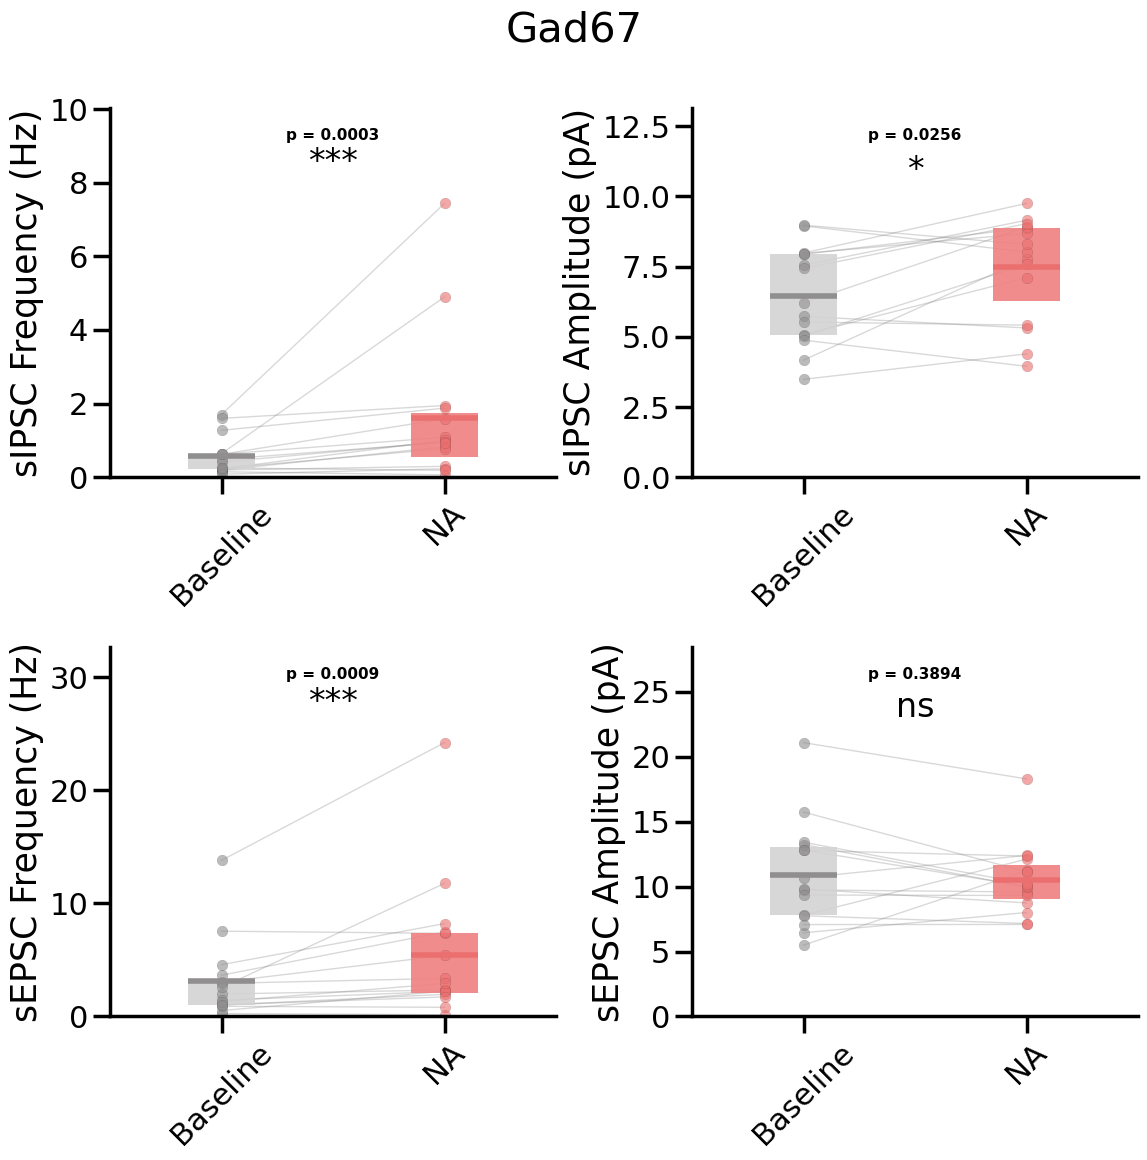

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib
import pyabf 
import seaborn as sns
sns.set_context('poster')
import os
from scipy import stats
from statannotations.Annotator import Annotator

sEPSC_Gad67_freq

def plot_epsc_ipsc():
    # Create DataFrames
    df_sEPSC_freq = pd.DataFrame(sEPSC_Gad67_freq)
    df_sEPSC_ampl = pd.DataFrame(sEPSC_Gad67_ampl)
    df_sIPSC_freq = pd.DataFrame(sIPSC_Gad67_freq)
    df_sIPSC_ampl = pd.DataFrame(sIPSC_Gad67_ampl)
    
    # Create 2x2 plot
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    plt.subplots_adjust(wspace=0.3, hspace=0.)
    
    # Your exact color scheme
    colors = ['lightgrey', 'lightcoral']  # baseline, NA
    colors_bar = ["#908E8E", "#EB6F6F"]  # baseline, NA
    conditions = ['baseline', 'NA']
    
    datasets = [
        (df_sIPSC_freq, 'Baseline_Frequency', 'NA_Frequency', 'sIPSC Frequency (Hz)', axes[0,0]),
        (df_sIPSC_ampl, 'Baseline_Amplitude', 'NA_Amplitude', 'sIPSC Amplitude (pA)', axes[0,1]),
        (df_sEPSC_freq, 'Baseline_Frequency', 'NA_Frequency', 'sEPSC Frequency (Hz)', axes[1,0]),
        (df_sEPSC_ampl, 'Baseline_Amplitude', 'NA_Amplitude', 'sEPSC Amplitude (pA)', axes[1,1])
    ]
    
    for df, baseline_col, na_col, ylabel, ax in datasets:
        box_data = [df[baseline_col].values, df[na_col].values]
        
        # Plot boxplots with your color scheme
        box = ax.boxplot(
            box_data,
            positions=range(len(conditions)),
            widths=0.3,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color='none'),
            boxprops=dict(facecolor='none', edgecolor='none'),
            whiskerprops=dict(color='none'),
            capprops=dict(color='none')
        )
        
        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.9)
        
        # Plot connected lines and points
        for _, row in df.iterrows():
            y = [row[baseline_col], row[na_col]]
            x = [0, 1]
            
            # Connect points with line
            ax.plot(x, y, color='gray', alpha=0.3, linewidth=1, zorder=1)
            
            for i, (xi, yi) in enumerate(zip(x, y)):
                ax.scatter(xi, yi, color=colors_bar[i], alpha=0.6, s=60, zorder=2,
                          edgecolors='black', linewidths=0.1)
        
        # Draw mean lines
        for i, col in enumerate([baseline_col, na_col]):
            box_width = 0.3  # Same as the boxplot width
            y_vals = df[col].dropna().values
            if len(y_vals) > 0:
                ax.hlines(np.mean(y_vals),  i - box_width/2, i + box_width/2,
                         color=colors_bar[i], linewidth=4, zorder=3)
        
        data_long = pd.DataFrame({
            'value': np.concatenate([df[baseline_col].values, df[na_col].values]),
            'group': ['Baseline'] * len(df[baseline_col]) + ['NA'] * len(df[na_col])
        })
        
        # Configure statannotations for stars only with Wilcoxon paired test
        pairs = [('Baseline', 'NA')]
        annotator = Annotator(ax, pairs, data=data_long, x='group', y='value')
        annotator.configure(
            test='Wilcoxon', 
            text_format='star',  # Use stars instead of p-values
            loc='outside',  # Place annotations outside the plot
            verbose=False,
            line_height=0,  # Remove the bracket lines
            line_width=0    # Remove the bracket lines
        )
        annotator.apply_and_annotate()
    
        # Get max_y for axis formatting
        max_y = max(df[baseline_col].max(), df[na_col].max())
        if max_y <= 0:
            max_y = 1
        
        # Also show numeric p-value above the star/ns annotation (Wilcoxon)
        paired = df[[baseline_col, na_col]].dropna()
        if len(paired) > 0:
            try:
                _, p_val = stats.wilcoxon(paired[baseline_col], paired[na_col])
            except ValueError:
                p_val = np.nan
        else:
            p_val = np.nan
        p_text = f'p = {p_val:.4f}' if np.isfinite(p_val) else 'p = n/a'
        p_text_y = max_y + (max_y * 0.22)
        ax.text(0.5, p_text_y, p_text,
                ha='center', va='bottom', fontsize=11, fontweight='bold')
        
        # Format axes
        ax.set_ylabel(ylabel, fontsize=25)
        ax.set_xticks(range(len(conditions)))
        ax.set_xticklabels(['Baseline', 'NA'], rotation=45)
        ax.set_xlim(-0.5, len(conditions) - 0.5)
        ax.set_ylim(0, max_y + (max_y * 0.35))

        
        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    fig.suptitle('Gad67', fontsize=30, y=0.98)
    plt.tight_layout()
    #plt.savefig("spont_stats.pdf", dpi=300)
    plt.show()

# Run the function
plot_epsc_ipsc()

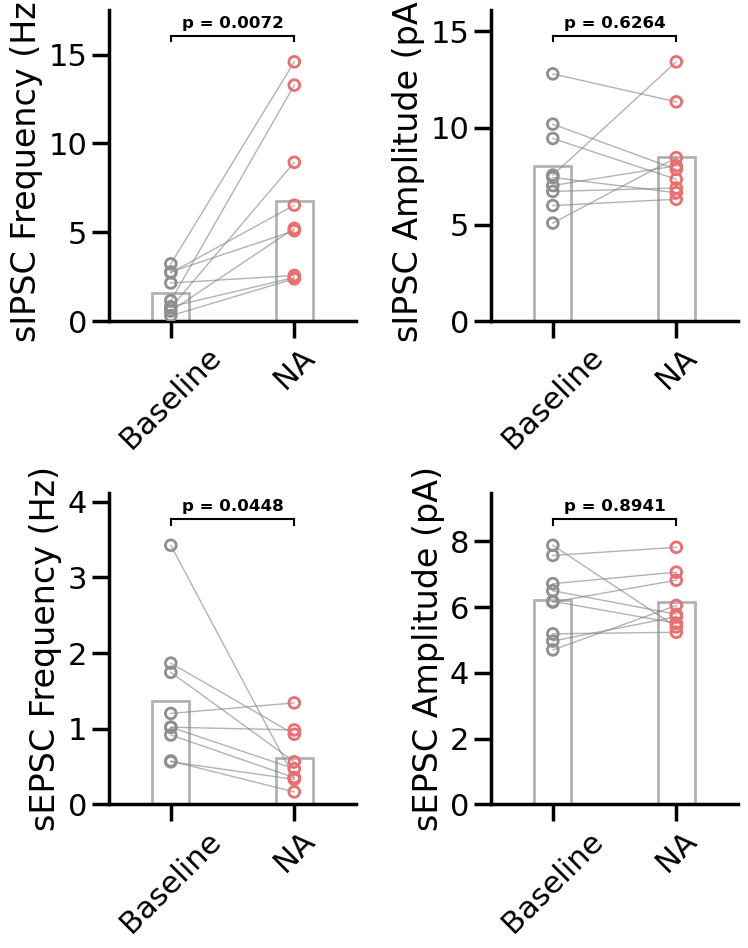

In [6]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib
import pyabf 
import seaborn as sns
sns.set_context('poster')
import os
from scipy import stats

def plot_epsc_ipsc():
    # Create DataFrames
    df_sEPSC_freq = pd.DataFrame(sEPSC_ntsr1_freq)
    df_sEPSC_ampl = pd.DataFrame(sEPSC_ntsr1_ampl)
    df_sIPSC_freq = pd.DataFrame(sIPSC_ntsr1_freq)
    df_sIPSC_ampl = pd.DataFrame(sIPSC_ntsr1_ampl)
    
    # Create 2x2 plot
    fig, axes = plt.subplots(2, 2, figsize=(8, 10))
    plt.subplots_adjust(wspace=0.3, hspace=0.4)
    
    # Your exact color scheme (for circle outlines)
    colors_outline = ["#908E8E", "#EB6F6F"]  # baseline, NA
    conditions = ['Baseline', 'NA']
    
    datasets = [
        (df_sIPSC_freq, 'Baseline_Frequency', 'NA_Frequency', 'sIPSC Frequency (Hz)', axes[0,0]),
        (df_sIPSC_ampl, 'Baseline_Amplitude', 'NA_Amplitude', 'sIPSC Amplitude (pA)', axes[0,1]),
        (df_sEPSC_freq, 'Baseline_Frequency', 'NA_Frequency', 'sEPSC Frequency (Hz)', axes[1,0]),
        (df_sEPSC_ampl, 'Baseline_Amplitude', 'NA_Amplitude', 'sEPSC Amplitude (pA)', axes[1,1])
    ]
    
    for df, baseline_col, na_col, ylabel, ax in datasets:
        # Calculate means and standard deviations
        baseline_mean = df[baseline_col].mean()
        na_mean = df[na_col].mean()

        
        means = [baseline_mean, na_mean]
        # Create outlined bar plot
        bars = ax.bar(range(len(conditions)), means, 
                     width=0.3, 
                     fill=False,  # No fill
                     edgecolor='gray',
                     linewidth=2,
                     alpha=0.6)
        
        
        # Plot individual data points with colored outlines (not filled)
        for _, row in df.iterrows():
            y_vals = [row[baseline_col], row[na_col]]
            x_vals = [0, 1]
            
            # Connect points with line
            ax.plot(x_vals, y_vals, color='gray', alpha=0.6, linewidth=1, zorder=1)
            
            # Plot circles with colored outlines
            for i, (x, y) in enumerate(zip(x_vals, y_vals)):
                ax.scatter(x, y, s=60, facecolors='none',  # No fill
                          edgecolors=colors_outline[i], 
                          linewidths=2, zorder=3)
        
        # Calculate p-value
        t_stat, p_val = stats.ttest_rel(df[baseline_col], df[na_col])
        max_y = max(df[baseline_col].max(), df[na_col].max())
        
        # Add significance line and p-value
        line_y = max_y + max_y * 0.1
        ax.plot([0, 1], [line_y, line_y], color='black', linewidth=1.5)
        ax.plot([0, 0], [line_y - max_y * 0.02, line_y], color='black', linewidth=1.5)
        ax.plot([1, 1], [line_y - max_y * 0.02, line_y], color='black', linewidth=1.5)
        
        ax.text(0.5, line_y + max_y * 0.02, f'p = {p_val:.4f}', 
                ha='center', va='bottom', fontsize=12, fontweight='bold')
        
        # Format axes
        ax.set_ylabel(ylabel)
        ax.set_xticks(range(len(conditions)))
        ax.set_xticklabels(conditions, rotation=45)
        ax.set_xlim(-0.5, len(conditions) - 0.5)
        ax.set_ylim(0, max_y + max_y * 0.2)
        
        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Run the function
plot_epsc_ipsc()

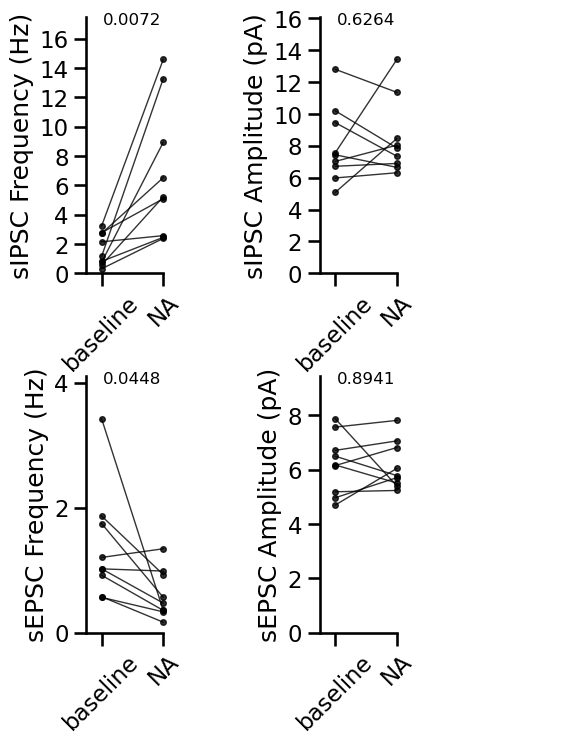

In [5]:

def plot_epsc_ipsc():
    # Create DataFrames
    df_sEPSC_freq = pd.DataFrame(sEPSC_ntsr1_freq)
    df_sEPSC_ampl = pd.DataFrame(sEPSC_ntsr1_ampl)
    df_sIPSC_freq = pd.DataFrame(sIPSC_ntsr1_freq)
    df_sIPSC_ampl = pd.DataFrame(sIPSC_ntsr1_ampl)
    
    # Create 2x2 plot
    fig, axes = plt.subplots(2, 2, figsize=(6, 8))
    plt.subplots_adjust(wspace=0.01, hspace=0.4)

    # Color scheme matching the other script
    colors = ['lightgrey', 'lightcoral']  # baseline, NA
    colors_bar = ["#908E8E", "#EB6F6F"]  # baseline, NA
    conditions = ['baseline', 'NA']
    
    datasets = [
        (df_sIPSC_freq, 'Baseline_Frequency', 'NA_Frequency', 'sIPSC Frequency (Hz)', axes[0,0]),
        (df_sIPSC_ampl, 'Baseline_Amplitude', 'NA_Amplitude', 'sIPSC Amplitude (pA)', axes[0,1]),
        (df_sEPSC_freq, 'Baseline_Frequency', 'NA_Frequency', 'sEPSC Frequency (Hz)', axes[1,0]),
        (df_sEPSC_ampl, 'Baseline_Amplitude', 'NA_Amplitude', 'sEPSC Amplitude (pA)', axes[1,1])
    ]
    
    for df, baseline_col, na_col, ylabel, ax in datasets:
        # Plot connected dots
        for _, row in df.iterrows():
            ax.plot([0, 1], [row[baseline_col], row[na_col]], 
                   'o-', color='black', markersize=4, linewidth=1, alpha=0.8)
        
        # Calculate and display p-value
        t_stat, p_val = stats.ttest_rel(df[baseline_col], df[na_col])
        max_y = max(df[baseline_col].max(), df[na_col].max())
        ax.text(0.5, max_y + (max_y * 0.15), f'{p_val:.4f}', 
                ha='center', va='bottom', fontsize=12)
        
        # Format axes
        ax.set_ylabel(ylabel)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['baseline', 'NA'], rotation=45)
        
        # Set tight x-axis limits that match the data points
        ax.set_xlim(-0.25, 3.5)
        
        # Set y-axis limit with space for p-value
        ax.set_ylim(0, max_y + (max_y * 0.2))

        # Set y-axis ticks every 5 units
        ax.yaxis.set_major_locator(MultipleLocator(2))
        
        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Adjust spine lengths to match x-axis limits
        ax.spines['bottom'].set_bounds(-0.25, 1)
        ax.spines['left'].set_bounds(0, ax.get_ylim()[1])
    
    plt.show()

# Run the function
plot_epsc_ipsc()

In [14]:
"""
Statistical Analysis: ntsr1 vs GAD67 Datasets
Compares Baseline vs NA conditions using appropriate statistical tests
Automatically selects paired t-test or Wilcoxon based on data normality
"""

import numpy as np
import pandas as pd
from scipy import stats

# ============================================================================
# NTSR1 DATASET
# ============================================================================

sEPSC_ntsr1_freq = {
    'Cell_ID': ['M1_C1', 'M1_C2', 'M1_C3', 'M2_C1', 'M2_C2', 'M2_C3', 'M6_C1', 'M6_C2', 'M6_C3'],
    'Animal': ['M1', 'M1', 'M1', 'M2', 'M2', 'M2', 'M6', 'M6', 'M6'],
    'Baseline_Frequency': [1.8677, 0.575, 1.0208, 0.5641, 1.2033, 0.9186, 3.4255, 1.7464, 1.0217],
    'NA_Frequency': [0.9283, 0.1662, 0.9855, 0.3319, 1.3427, 0.3547, 0.3552, 0.5639, 0.4719]
}

sEPSC_ntsr1_ampl = {
    'Cell_ID': ['M1_C1', 'M1_C2', 'M1_C3', 'M2_C1', 'M2_C2', 'M2_C3', 'M6_C1', 'M6_C2', 'M6_C3'],
    'Animal': ['M1', 'M1', 'M1', 'M2', 'M2', 'M2', 'M6', 'M6', 'M6'],
    'Baseline_Amplitude': [7.5706, 6.7139, 6.1536, 5.188, 6.499, 4.9682, 7.8805, 6.1763, 4.6996],
    'NA_Amplitude': [7.8184, 7.0626, 6.8185, 5.2362, 5.7827, 5.7086, 5.3993, 5.5099, 6.0505]
}

sIPSC_ntsr1_freq = {
    'Cell_ID': ['M3_C1', 'M3_C2', 'M3_C3', 'M4_C1', 'M4_C2', 'M4_C3', 'M5_C1', 'M5_C2', 'M5_C3'],
    'Animal': ['M3', 'M3', 'M3', 'M4', 'M4', 'M4', 'M5', 'M5', 'M5'],
    'Baseline_Frequency': [1.1462, 0.563, 2.7665, 2.1435, 0.3021, 0.7454, 0.8081, 3.221020878, 2.7158],
    'NA_Frequency': [13.281, 5.2162, 5.0844, 2.5665, 2.378, 8.9352, 2.4505, 14.592, 6.5217]
}

sIPSC_ntsr1_ampl = {
    'Cell_ID': ['M3_C1', 'M3_C2', 'M3_C3', 'M4_C1', 'M4_C2', 'M4_C3', 'M5_C1', 'M5_C2', 'M5_C3'],
    'Animal': ['M3', 'M3', 'M3', 'M4', 'M4', 'M4', 'M5', 'M5', 'M5'],
    'Baseline_Amplitude': [10.198, 6.7138, 7.0191, 7.4348, 5.0756, 12.802, 5.9815, 7.559096154, 9.455],
    'NA_Amplitude': [7.8551, 6.8923, 8.0405, 6.6456, 8.4617, 11.353, 6.3087, 13.425, 7.3418]
}

# ============================================================================
# GAD67 DATASET
# ============================================================================

sEPSC_Gad67_freq = {
    'Cell_ID': ['M1_C1', 'M1_C2', 'M1_C3', 'M2_C1', 'M2_C2', 'M2_C3', 'M3_C1', 'M3_C2', 'M3_C3', 'M4_C1', 'M4_C2', 'M4_C3', 'M5_C1', 'M5_C2', 'M5_C3'],
    'Animal': ['M1', 'M1', 'M1', 'M2', 'M2', 'M2', 'M3', 'M3', 'M3', 'M4', 'M4', 'M4', 'M5', 'M5', 'M5'],
    'Baseline_Frequency': [1.0086, 0.2561, 3.0418, 1.9863, 7.5441, 2.9273, 3.6544, 1.4384, 0.9005, 4.5827, 13.808, 0.5264, 2.5691, 1.3247, 1.0313],
    'NA_Frequency': [1.9585, 0.1517, 5.3941, 2.3442, 7.3563, 3.3679, 7.4706, 2.2165, 0.812, 8.2118, 24.223, 2.2272, 11.774, 2.9194, 1.7295]
}

sEPSC_Gad67_ampl = {
    'Cell_ID': ['M1_C1', 'M1_C2', 'M1_C3', 'M2_C1', 'M2_C2', 'M2_C3', 'M3_C1', 'M3_C2', 'M3_C3', 'M4_C1', 'M4_C2', 'M4_C3', 'M5_C1', 'M5_C2', 'M5_C3'],
    'Animal': ['M1', 'M1', 'M1', 'M2', 'M2', 'M2', 'M3', 'M3', 'M3', 'M4', 'M4', 'M4', 'M5', 'M5', 'M5'],
    'Baseline_Amplitude': [6.4446, 5.4932, 9.7401, 7.7907, 9.8147, 10.673, 7.7534, 9.3481, 13.235, 12.809, 13.409, 7.0745, 21.076, 15.731, 12.778],
    'NA_Amplitude': [8.0008, 11.215, 9.5827, 12.109, 8.7378, 12.397, 7.1545, 9.3114, 9.9535, 10.013, 10.212, 7.0827, 18.285, 11.137, 12.346]
}

sIPSC_Gad67_freq = {
    'Cell_ID': ['M1_C1', 'M1_C2', 'M1_C3', 'M2_C1', 'M2_C2', 'M2_C3', 'M3_C1', 'M3_C2', 'M3_C3', 'M4_C1', 'M4_C2', 'M4_C3', 'M5_C1', 'M5_C2', 'M5_C3'],
    'Animal': ['M1', 'M1', 'M1', 'M2', 'M2', 'M2', 'M3', 'M3', 'M3', 'M4', 'M4', 'M4', 'M5', 'M5', 'M5'],
    'Baseline_Frequency': [0.6272, 0.149, 1.7039, 0.6419, 0.1978, 0.2319, 0.4106, 1.5999, 0.1948, 1.2751, 0.2411, 0.4877, 0.0827, 0.6229, 0.2523],
    'NA_Frequency': [1.086, 0.0648, 7.4388, 4.8996, 0.2967, 1.0022, 0.9678, 1.9486, 0.8286, 1.8771, 0.7785, 0.9436, 0.2305, 1.5879, 0.1887]
}

sIPSC_Gad67_ampl = {
    'Cell_ID': ['M1_C1', 'M1_C2', 'M1_C3', 'M2_C1', 'M2_C2', 'M2_C3', 'M3_C1', 'M3_C2', 'M3_C3', 'M4_C1', 'M4_C2', 'M4_C3', 'M5_C1', 'M5_C2', 'M5_C3'],
    'Animal': ['M1', 'M1', 'M1', 'M2', 'M2', 'M2', 'M3', 'M3', 'M3', 'M4', 'M4', 'M4', 'M5', 'M5', 'M5'],
    'Baseline_Amplitude': [5.7305, 4.1707, 7.5538, 7.9447, 6.2053, 5.0735, 5.0281, 7.986, 8.9519, 5.5295, 7.9685, 8.9782, 4.8826, 7.4366, 3.4877],
    'NA_Amplitude': [5.3163, 7.782, 9.1526, 8.8745, 8.9111, 7.1068, 7.585, 9.7527, 8.0184, 5.4163, 8.6818, 8.2915, 3.9513, 9.0303, 4.3945]
}

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def test_normality(data):
    """Shapiro-Wilk normality test (returns True if normal, p-value)"""
    stat, p = stats.shapiro(data)
    return p > 0.05, p

def cohen_d(baseline, na):
    """Calculate Cohen's d effect size"""
    pooled_std = np.sqrt((np.std(baseline, ddof=1)**2 + np.std(na, ddof=1)**2) / 2)
    return (np.mean(na) - np.mean(baseline)) / pooled_std if pooled_std != 0 else 0

def run_test(baseline, na):
    """
    Run appropriate statistical test based on data characteristics
    Returns: test_name, statistic, p_value, effect_size
    """
    baseline = np.array(baseline)
    na = np.array(na)
    
    normal_base, _ = test_normality(baseline)
    normal_na, _ = test_normality(na)
    n = len(baseline)
    
    # Use t-test if both normal and n >= 5, otherwise Wilcoxon
    if normal_base and normal_na and n >= 5:
        t_stat, p_val = stats.ttest_rel(baseline, na)
        effect = cohen_d(baseline, na)
        return "t-test", t_stat, p_val, effect
    else:
        w_stat, p_val = stats.wilcoxon(baseline, na)
        # Rank-biserial correlation as effect size
        effect = 1 - (2 * w_stat) / (n * (n + 1))
        return "Wilcoxon", w_stat, p_val, effect

def analyze(data_dict, synaptic, measure):
    """
    Analyze one measurement condition
    Returns dict with statistics
    """
    if measure == "Frequency":
        baseline = data_dict['Baseline_Frequency']
        na = data_dict['NA_Frequency']
    else:
        baseline = data_dict['Baseline_Amplitude']
        na = data_dict['NA_Amplitude']
    
    baseline = np.array(baseline)
    na = np.array(na)
    
    test, stat, pval, effect = run_test(baseline, na)
    change = ((np.mean(na) - np.mean(baseline)) / np.mean(baseline) * 100) if np.mean(baseline) != 0 else 0
    
    # Significance code
    if pval < 0.001:
        sig = '***'
    elif pval < 0.01:
        sig = '**'
    elif pval < 0.05:
        sig = '*'
    else:
        sig = 'ns'
    
    return {
        'Synaptic': synaptic,
        'Measure': measure,
        'N': len(baseline),
        'Baseline': f"{np.mean(baseline):.4f}±{np.std(baseline, ddof=1):.4f}",
        'NA': f"{np.mean(na):.4f}±{np.std(na, ddof=1):.4f}",
        'Change %': f"{change:.1f}%",
        'Test': test,
        'Statistic': f"{stat:.4f}",
        'P-value': f"{pval:.4f}",
        'Sig': sig,
        'Effect': f"{effect:.4f}"
    }

# ============================================================================
# MAIN ANALYSIS
# ============================================================================

if __name__ == '__main__':
    print("="*140)
    print("STATISTICAL ANALYSIS: ntsr1 vs GAD67 DATASETS".center(140))
    print("="*140)
    
    results = []
    
    # NTSR1
    print("\nNTSR1 DATASET".center(140, "="))
    results.append(analyze(sEPSC_ntsr1_freq, 'sEPSC', 'Frequency'))
    results.append(analyze(sEPSC_ntsr1_ampl, 'sEPSC', 'Amplitude'))
    results.append(analyze(sIPSC_ntsr1_freq, 'sIPSC', 'Frequency'))
    results.append(analyze(sIPSC_ntsr1_ampl, 'sIPSC', 'Amplitude'))
    
    ntsr1_df = pd.DataFrame(results)
    print(ntsr1_df.to_string(index=False))
    
    # GAD67
    print("\n\nGAD67 DATASET".center(140, "="))
    results = []
    results.append(analyze(sEPSC_Gad67_freq, 'sEPSC', 'Frequency'))
    results.append(analyze(sEPSC_Gad67_ampl, 'sEPSC', 'Amplitude'))
    results.append(analyze(sIPSC_Gad67_freq, 'sIPSC', 'Frequency'))
    results.append(analyze(sIPSC_Gad67_ampl, 'sIPSC', 'Amplitude'))
    
    gad67_df = pd.DataFrame(results)
    print(gad67_df.to_string(index=False))
    
    # Save combined results
    ntsr1_df['Dataset'] = 'ntsr1'
    gad67_df['Dataset'] = 'GAD67'
    combined = pd.concat([ntsr1_df, gad67_df], ignore_index=True)
    combined = combined[['Dataset'] + [c for c in combined.columns if c != 'Dataset']]
    combined.to_csv('statistical_results.csv', index=False)
    
    # Print summary
    print("\n\n" + "SUMMARY".center(140, "="))
    print("\nSignificance codes: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
    print("\nTest Selection Logic:")
    print("  • Paired t-test: Used when both baseline and NA data are normally distributed (Shapiro-Wilk p>0.05)")
    print("  • Wilcoxon signed-rank: Used when data violates normality assumption")
    print("\nEffect Size Interpretation:")
    print("  • t-test (Cohen's d): |d| < 0.2 = small, 0.2-0.8 = medium, > 0.8 = large")
    print("  • Wilcoxon (rank-biserial r): |r| < 0.1 = small, 0.1-0.3 = medium, > 0.3 = large")
    print("\n✓ Results saved to: statistical_results.csv")

                                               STATISTICAL ANALYSIS: ntsr1 vs GAD67 DATASETS                                                
NTSR1 DATASET===============================================================
Synaptic   Measure  N      Baseline            NA Change %     Test Statistic P-value Sig  Effect
   sEPSC Frequency  9 1.3715±0.8924 0.6111±0.3881   -55.4% Wilcoxon    2.0000  0.0117   *  0.9556
   sEPSC Amplitude  9 6.2055±1.1097 6.1541±0.8811    -0.8%   t-test    0.1374  0.8941  ns -0.0513
   sIPSC Frequency  9 1.6013±1.1097 6.7806±4.5989   323.4%   t-test   -3.5777  0.0072  **  1.5483
   sIPSC Amplitude  9 8.0265±2.3916 8.4804±2.3766     5.7% Wilcoxon   21.0000  0.9102  ns  0.5333

GAD67 DATASET===============================================================
Synaptic   Measure  N       Baseline             NA Change %     Test Statistic P-value Sig Effect
   sEPSC Frequency 15  3.1066±3.5111  5.4771±6.1214    76.3% Wilcoxon    6.0000  0.0009 *** 0.9500
   sEPSC Amplitu